# Confusion Matrix → TikZ

This notebook demonstrates:

- Creating a confusion matrix with **scikit-learn**
- Plotting it with **matplotlib**

The generated TikZ code follows the same structure as the example you provided (`matrix plot` + `point meta=explicit` + inline `table [meta=C] { ... }`).


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

## 1) Example data (y_true / y_pred)

We’ll create a small example with two classes: `brass`, `acrylic`.


In [2]:
labels = ["brass", "acrylic"]

# Ground-truth and predictions (simple, explicit example)
# - 1000 samples of class 0, 1000 samples of class 1
# - 2 mistakes: class 0 predicted as class 1
y_true = np.array([0] * 1000 + [1] * 1000)
y_pred = np.array([0] * 998 + [1] * 2 + [1] * 1000)

len(y_true), len(y_pred)

(2000, 2000)

## 2) Confusion matrix (scikit-learn)

In [3]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm

array([[ 998,    2],
       [   0, 1000]])

## 3) Matplotlib plot (scikit-learn helper)

This is the standard scikit-learn `ConfusionMatrixDisplay` rendered with matplotlib.


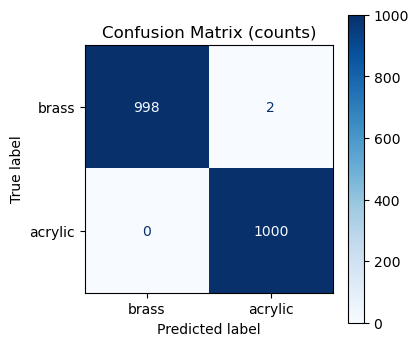

In [4]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
ax.set_title("Confusion Matrix (counts)")
plt.show()

## 4) TikZ generator class

- `normalize=True` converts counts to percentages in `[0, 100]` (like your example).
- Output includes inline `table [meta=C] { x y C ... }`.
- The label strings are minimally TeX-escaped.


In [5]:
from plotLaTeX import ConfusionMatrix

In [6]:
tikz_code = (
    ConfusionMatrix()
    .from_confusion_matrix(cm, labels)
    .tikz(xlabel="Predicted class", ylabel="True class", normalize=True, decimals=2)
)

print(tikz_code)

% imports
\usepackage{tikz}
\usepackage{pgfplots}
\pgfplotsset{compat=1.18}
\usetikzlibrary{shapes,positioning,fit,arrows.meta,decorations.pathreplacing}

\begin{tikzpicture}[]
	\begin{axis}[
		width=5cm,
		height=5cm,
		colormap={blue}{color=(white) color=(blue)},
		xticklabels={brass, acrylic},
		xtick={0,...,1},
		xtick style={draw=none},
		yticklabels={brass, acrylic},
		ytick={0,...,1},
		ytick style={draw=none},
		xlabel={Predicted class},
		ylabel={True class},
		enlargelimits=false,
		colorbar,
		colorbar style={
			plot graphics/node/.style={scale=1.33,anchor=south west,inner sep=0pt,},
			ytick={0,20,40,60,80,100},
			yticklabels={0,0.2,0.4,0.6,0.8,1.0},
			yticklabel={\pgfmathprintnumber\tick},
			yticklabel style={
				/pgf/number format/fixed,
				/pgf/number format/precision=1}
		},
		point meta min=0.0,point meta max=100.0,
		nodes near coords={\pgfmathprintnumber\pgfplotspointmeta},
		nodes near coords style={
			yshift=-7pt,
			/pgf/number format/fixed,
			/pgf/number 

## 6) (Optional) TikZ with raw counts instead of percentages

Set `normalize=False` to embed raw counts and adjust `point_meta_max` if you want a consistent colormap scale.


In [7]:
tikz_counts = (
    ConfusionMatrix()
    .from_confusion_matrix(cm, labels)
    .tikz(
        xlabel="Predicted class",
        ylabel="True class",
        normalize=False,
        decimals=0,
        point_meta_min=0.0,
        point_meta_max=float(cm.max()),
    )
)

print(tikz_counts)

% imports
\usepackage{tikz}
\usepackage{pgfplots}
\pgfplotsset{compat=1.18}
\usetikzlibrary{shapes,positioning,fit,arrows.meta,decorations.pathreplacing}

\begin{tikzpicture}[]
	\begin{axis}[
		width=5cm,
		height=5cm,
		colormap={blue}{color=(white) color=(blue)},
		xticklabels={brass, acrylic},
		xtick={0,...,1},
		xtick style={draw=none},
		yticklabels={brass, acrylic},
		ytick={0,...,1},
		ytick style={draw=none},
		xlabel={Predicted class},
		ylabel={True class},
		enlargelimits=false,
		colorbar,
		colorbar style={
			plot graphics/node/.style={scale=1.33,anchor=south west,inner sep=0pt,},
			ytick={0,20,40,60,80,100},
			yticklabels={0,0.2,0.4,0.6,0.8,1.0},
			yticklabel={\pgfmathprintnumber\tick},
			yticklabel style={
				/pgf/number format/fixed,
				/pgf/number format/precision=1}
		},
		point meta min=0.0,point meta max=1000.0,
		nodes near coords={\pgfmathprintnumber\pgfplotspointmeta},
		nodes near coords style={
			yshift=-7pt,
			/pgf/number format/fixed,
			/pgf/number

___